# Lesson 18｜Matplotlib 與圖表選擇

共 25 個逐步示範，請依序執行。

> 本課已附上 `lesson18_sales.csv`。請讓 CSV 與 Notebook 保持在同一個資料夾。


## 01｜讀取並準備畫圖資料

日期先轉成 datetime，營業額先算好。


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
print(df.head())
print(df.dtypes)


  order_id       date customer_id       city category product  quantity  \
0     O001 2026-01-02        C001     Taipei    Snack  Cookie         1   
1     O002 2026-01-05        C006   Taichung    Daily  Tissue         2   
2     O003 2026-01-08        C011  Kaohsiung    Drink  Coffee         3   
3     O004 2026-01-11        C016     Tainan    Snack   Chips         4   
4     O005 2026-01-14        C004     Taipei    Daily    Soap         5   

   unit_price payment  revenue  
0          55    cash       55  
1          80  mobile      160  
2         120    card      360  
3          45    cash      180  
4         110  mobile      550  
order_id               object
date           datetime64[ns]
customer_id            object
city                   object
category               object
product                object
quantity                int64
unit_price              int64
payment                object
revenue                 int64
dtype: object


## 02｜認識 pyplot

plt 是 Matplotlib 常見縮寫，負責建立與顯示圖表。


In [1]:
import matplotlib.pyplot as plt

print("Matplotlib 已準備完成")


Matplotlib 已準備完成


## 03｜第一張長條圖

長條圖適合比較不同類別的大小。


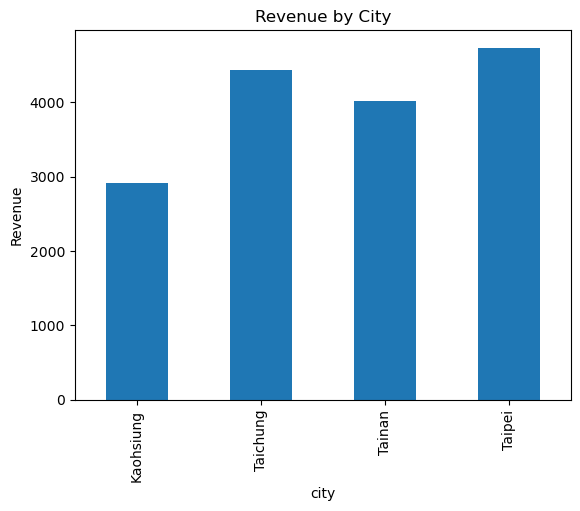

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
city_revenue = df.groupby("city")["revenue"].sum()
city_revenue.plot(kind="bar")
plt.title("Revenue by City")
plt.ylabel("Revenue")
plt.show()


## 04｜排序後再畫長條圖

由大到小排列，觀眾更容易看出排名。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
city_revenue = df.groupby("city")["revenue"].sum().sort_values(ascending=False)
city_revenue.plot(kind="bar", color="#2A9D8F")
plt.title("Revenue Ranking by City")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
#在使用 Pandas 繪製直方圖/長條圖 plot(kind="bar") 時
# Pandas 預設會將 X 軸文字旋轉 90 度（變垂直）。
plt.show()


## 05｜在長條上標示數值

少量類別可以直接顯示數字，方便精確比較。


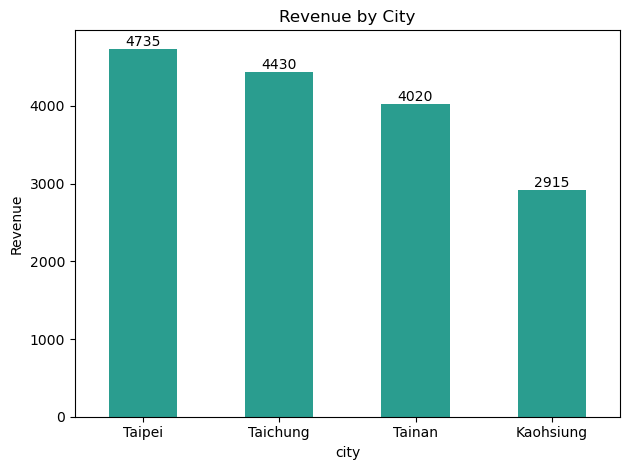

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
city_revenue = df.groupby("city")["revenue"].sum().sort_values(ascending=False)
ax = city_revenue.plot(kind="bar", color="#2A9D8F")
ax.bar_label(ax.containers[0], padding=0)#在長條圖的柱子頂端自動顯示數據標籤（數值）
plt.title("Revenue by City")
plt.ylabel("Revenue")
plt.xticks(rotation=0)#將x軸上原本旋轉 90 度的文字變垂直
plt.tight_layout()#自動調整圖表的版面邊界與元素間距
plt.show()


## 06｜橫向長條圖適合較長名稱

barh 能讓分類名稱保留更多水平空間。


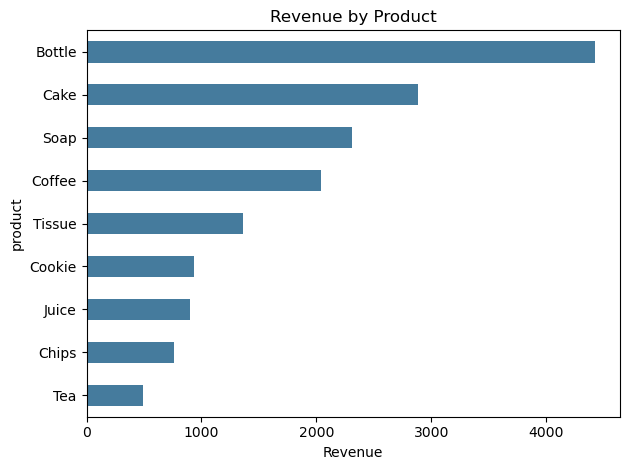

In [18]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
product_revenue = df.groupby("product")["revenue"].sum().sort_values()
product_revenue.plot(kind="barh", color="#457B9D")
plt.title("Revenue by Product")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()


## 07｜折線圖呈現時間趨勢

時間放在橫軸，可以觀察上升、下降與轉折。


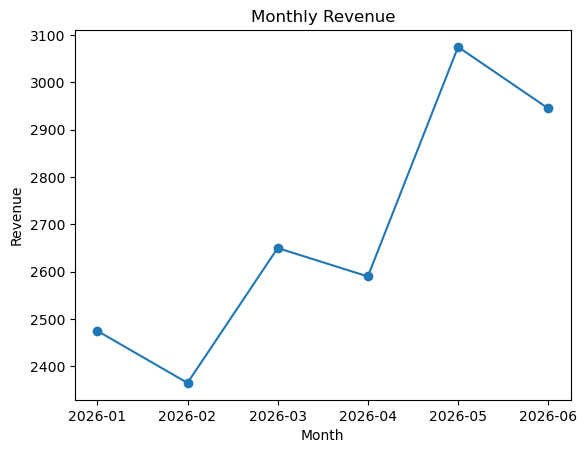

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
monthly = df.groupby(df["date"].dt.to_period("M"))["revenue"].sum()
#將日期轉為「月份週期」格式（例如將 "2026-09-01" 或 "2026-09-15" 統一轉為 "2026-09"）
##df.groupby(...)：以此月份進行分組
#["revenue"].sum()：計算每一個月份的營業額總和，並存入 monthly。
monthly.index = monthly.index.astype(str)
#將索引中的「月份週期型態（PeriodIndex）」轉換為「字串型態（string）」（如 '2026-09'）。
#原因：某些繪圖工具或版本的 Matplotlib 在處理 Period 型態時可能會出現座標軸相容性問題
# 轉成純字串可確保 X 軸上的月份文字能順利且乾淨地印出。
monthly.plot(kind="line", marker="o")
#kind="line"：繪製折線圖（最適合用來觀察時間趨勢，如月營收變化）。
#marker="o"：在折線圖的每個數據點（每個月的資料位置）上標註一個圓點，讓數據點的位置更清楚突出。
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


## 08｜畫折線圖前先排序日期

若時間順序錯亂，折線會傳達錯誤故事。


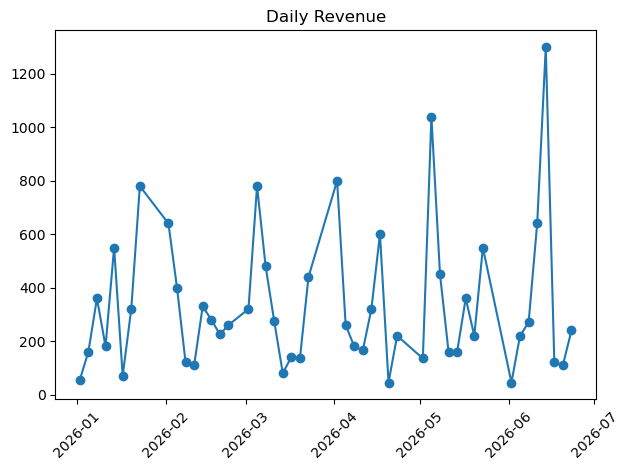

In [20]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
daily = df.groupby("date", as_index=False)["revenue"].sum()
daily = daily.sort_values("date")
plt.plot(daily["date"], daily["revenue"], marker="o")
plt.title("Daily Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 09｜用 marker 看清楚每個時間點

資料點不多時，marker 可以幫助對照每一期。


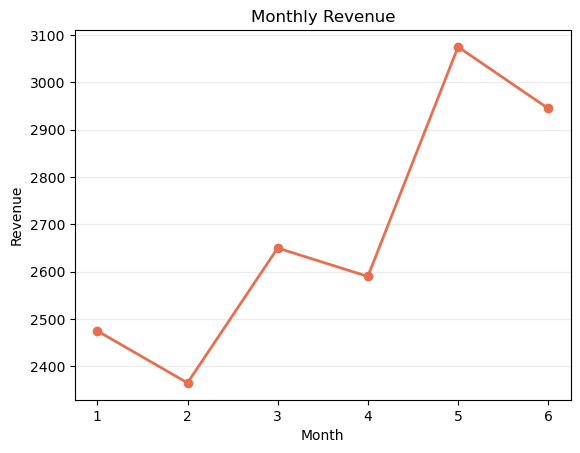

In [22]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
monthly = df.groupby(df["date"].dt.month)["revenue"].sum()
plt.plot(monthly.index, monthly.values, marker="o", linewidth=2, color="#E76F51")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(axis="y", alpha=0.25)
plt.show()


## 10｜多條折線比較商品分類

同一張圖的線條不宜太多，否則很難追蹤。


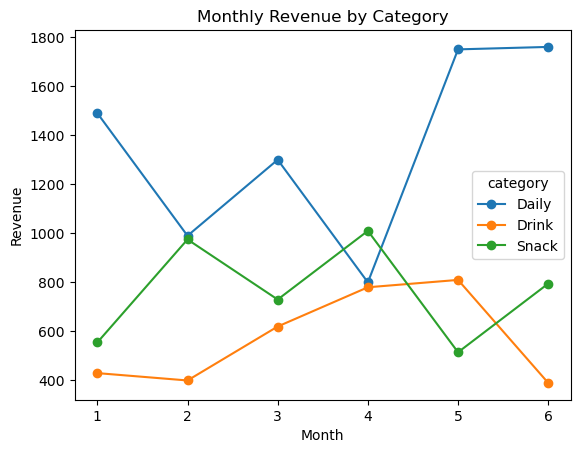

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
monthly_category = df.pivot_table(
    index=df["date"].dt.month,
    columns="category",
    values="revenue",
    aggfunc="sum"#aggfunc="sum"（計算方式）：設定聚合函數為加總（sum），即計算各月份中各類別的營業額總和。
)
monthly_category.plot(kind="line", marker="o")
plt.title("Monthly Revenue by Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


## 11｜圓餅圖顯示整體占比

分類少、加總為百分之百時，圓餅圖才容易閱讀。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
category_revenue = df.groupby("category")["revenue"].sum()
category_revenue.plot(kind="pie", autopct="%1.0f%%", startangle=90)
plt.title("Revenue Share by Category")
plt.ylabel("")
plt.show()


## 12｜圓餅圖不要塞太多分類

商品很多時改用排序長條圖，通常比較容易比較。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
product_revenue = df.groupby("product")["revenue"].sum().sort_values(ascending=False)
product_revenue.plot(kind="bar", color="#264653")
plt.title("Product Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 13｜散佈圖觀察兩個數字的關係

每個點是一筆訂單，用來觀察單價與數量是否一起變化。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
plt.scatter(df["unit_price"], df["quantity"], alpha=0.65, color="#F4A261")
plt.title("Unit Price and Quantity")
plt.xlabel("Unit Price")
plt.ylabel("Quantity")
plt.show()


## 14｜用顏色凸顯重點

其他類別使用中性色，重點類別使用醒目色。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
city_revenue = df.groupby("city")["revenue"].sum().sort_values(ascending=False)
colors = []
for city in city_revenue.index:
    if city == city_revenue.index[0]:
        colors.append("#E76F51")
    else:
        colors.append("#B8C4CC")
city_revenue.plot(kind="bar", color=colors)
plt.title("Top Revenue City")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()


## 15｜顏色要有一致的意思

同一份報告中，同一分類盡量維持同一顏色。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
category_colors = {"Drink": "#2A9D8F", "Snack": "#F4A261", "Daily": "#457B9D"}
category_revenue = df.groupby("category")["revenue"].sum()
colors = [category_colors[name] for name in category_revenue.index]
category_revenue.plot(kind="bar", color=colors)
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()


## 16｜figsize 控制畫布大小

投影片與 Notebook 可以使用不同大小，但比例要適合內容。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
city_revenue = df.groupby("city")["revenue"].sum()
plt.figure(figsize=(8, 4.5))
plt.bar(city_revenue.index, city_revenue.values, color="#2A9D8F")
plt.title("Revenue by City")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


## 17｜標題與軸標籤回答觀眾的疑問

標題說明圖表問題，軸標籤說明數字與分類。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
city_revenue = df.groupby("city")["revenue"].sum()
plt.bar(city_revenue.index, city_revenue.values)
plt.title("Which City Has the Highest Revenue?")
plt.xlabel("City")
plt.ylabel("Revenue (NTD)")
plt.show()


## 18｜淡淡的格線幫助估讀

格線應該輔助數字，不要搶走資料的注意力。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
monthly = df.groupby(df["date"].dt.month)["revenue"].sum()
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(axis="y", alpha=0.25)
plt.show()


## 19｜圖例只在需要辨認系列時出現

單一資料系列通常不需要圖例；多條線才需要。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
monthly_category = df.pivot_table(index=df["date"].dt.month, columns="category", values="revenue", aggfunc="sum")
monthly_category.plot(kind="line", marker="o")
plt.title("Monthly Revenue by Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(title="Category")
plt.show()


## 20｜長條圖通常從零開始

截斷縱軸會誇大類別之間的差異。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
city_revenue = df.groupby("city")["revenue"].sum()
city_revenue.plot(kind="bar", color="#457B9D")
plt.ylim(bottom=0)
plt.title("Revenue by City")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()


## 21｜savefig 儲存完成的圖表

先儲存再 show，能把圖片放進報告或 GitHub。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
city_revenue = df.groupby("city")["revenue"].sum()
city_revenue.plot(kind="bar", color="#2A9D8F")
plt.title("Revenue by City")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("lesson18_city_revenue.png", dpi=150)
plt.show()


## 22｜Pandas plot 是 Matplotlib 的快速入口

先用 Pandas 建圖，再用 plt 補標題與標籤。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
category_revenue = df.groupby("category")["revenue"].sum()
ax = category_revenue.plot(kind="bar", color="#2A9D8F")
ax.set_title("Revenue by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()


## 23｜依問題選擇圖表

比較類別用長條圖；時間趨勢用折線圖；少量占比才考慮圓餅圖。


In [ ]:
chart_guide = {
    "比較類別": "長條圖",
    "時間趨勢": "折線圖",
    "少量占比": "圓餅圖",
    "兩個數字的關係": "散佈圖"
}
for question, chart in chart_guide.items():
    print(question, "：", chart)


## 24｜標記最高的長條

標註能把讀者注意力帶到最重要的數字。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
city_revenue = df.groupby("city")["revenue"].sum().sort_values(ascending=False)
ax = city_revenue.plot(kind="bar", color="#B8C4CC")
ax.patches[0].set_color("#E76F51")
ax.annotate(
    f"Top: {city_revenue.iloc[0]:,.0f}",
    xy=(0, city_revenue.iloc[0]),
    xytext=(0, 8),
    textcoords="offset points",
    ha="center"
)
plt.title("Revenue Ranking by City")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()


## 25｜完成兩張圖的分析摘要

左邊比較城市，右邊觀察月份趨勢。


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("lesson18_sales.csv")
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["quantity"] * df["unit_price"]
city_revenue = df.groupby("city")["revenue"].sum().sort_values(ascending=False)
monthly = df.groupby(df["date"].dt.month)["revenue"].sum()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
city_revenue.plot(kind="bar", ax=axes[0], color="#2A9D8F")
axes[0].set_title("Revenue by City")
axes[0].set_ylabel("Revenue")
axes[0].tick_params(axis="x", rotation=0)
monthly.plot(kind="line", ax=axes[1], marker="o", color="#E76F51")
axes[1].set_title("Monthly Revenue")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Revenue")
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
